In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
import sympy as sp
from IPython.display import display

from functions import *

# Fresnel Equations

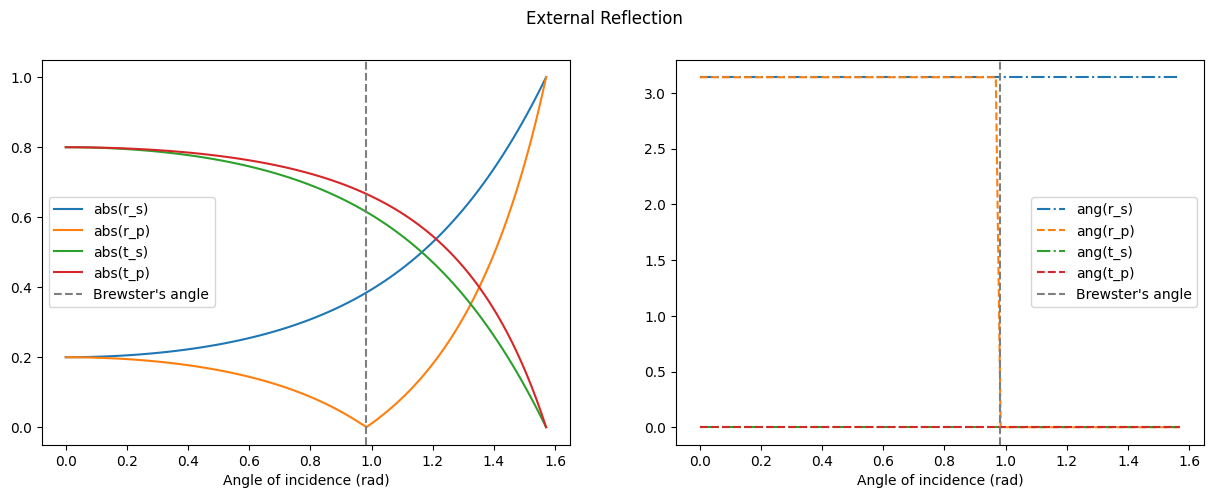

In [3]:
theta_list = np.linspace(0, np.pi/2, 100)

n1 = 1
n2 = 1.5
n = n2/n1
brewster_ang = np.arctan(n)

r_s_list, r_p_list = r_s(theta_list, n), r_p(theta_list, n)
t_s_list, t_p_list = t_s(theta_list, n), t_p(theta_list, n)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

if n>1:
    fig.suptitle('External Reflection')
else:
    fig.suptitle('Internal Reflection')
    crit_ang = np.arcsin(n)
    ax1.axvline(crit_ang, label = "critical angle", linestyle = '--', color = 'C4')
    ax2.axvline(crit_ang, label = "critical angle", linestyle = '--', color = 'C4')

ax1.plot(theta_list, np.abs(r_s_list), label="abs(r_s)")
ax1.plot(theta_list, np.abs(r_p_list), label="abs(r_p)")
ax1.plot(theta_list, np.abs(t_s_list), label="abs(t_s)")
ax1.plot(theta_list, np.abs(t_p_list), label="abs(t_p)")
ax1.set_xlabel('Angle of incidence (rad)')
ax1.axvline(brewster_ang, label = "Brewster's angle", linestyle = '--', color = 'C7')
ax1.legend()

ax2.plot(theta_list, np.angle(r_s_list), '-.', label="ang(r_s)")
ax2.plot(theta_list, np.angle(r_p_list), '--', label="ang(r_p)")
ax2.plot(theta_list, np.angle(t_s_list), '-.', label="ang(t_s)")
ax2.plot(theta_list, np.angle(t_p_list), '--', label="ang(t_p)")
ax2.axvline(brewster_ang, label = "Brewster's angle", linestyle = '--', color = 'C7')
ax2.set_xlabel('Angle of incidence (rad)')
ax2.legend()

plt.show()

# Fabry-Perot

Always run the cell bellow:

In [ ]:
n_s_val = 1.4 #substrate refractive index
n_o_val = 1 #air refractive index

lamb_list = np.linspace(1100, 1550, 500) #wavelengths (nm)

d_f = 4000 #thickness
# d_f = 8e3 - 5e3*(lamb_list-lamb_list[0])/(lamb_list[-1]-lamb_list[0])
# d_f = 8e3 - 5e2*(lamb_list-lamb_list[0])/(lamb_list[-1]-lamb_list[0])-3e2*(lamb_list-lamb_list[0])**2/(lamb_list[-1]-lamb_list[0])**2
# d_f = 8e3*np.log(10-(lamb_list-lamb_list[0])/(lamb_list[-1]-lamb_list[0]))

E0, Ed = 5.55, 8.90
n_f_val = n_Wemple_DiDomenico(lamb_list, E0, Ed) #refractive index
# n_f_val = 1.4*np.ones(len(lamb_list))

# Eu = 93.8e-3
Eu = 76e-3
# alpha0 = 10**(6-1/(np.log(10)*Eu)*3) #cm^-1
# alpha0 = 1e-2
alpha0 = 1e-3
alpha = alpha_Urbach(lamb_list, alpha0, Eu) #absorption coefficient (cm^-1)
kappa_f = alpha*lamb_list*10**-7/(4*np.pi) #complex refractive index
# kappa_f = 1e-3
phi_im = 2*np.pi*kappa_f/lamb_list * d_f
x_val = np.exp(-2*phi_im) #attenuation factor

n_s, n_f, n_o, phi, x = sp.symbols('n_s n_f n_o phi x', real = True)

R_Msqrt, R_msqrt, A, B, C, D = sp.symbols('R_Msqrt R_msqrt A B C D', real = True)

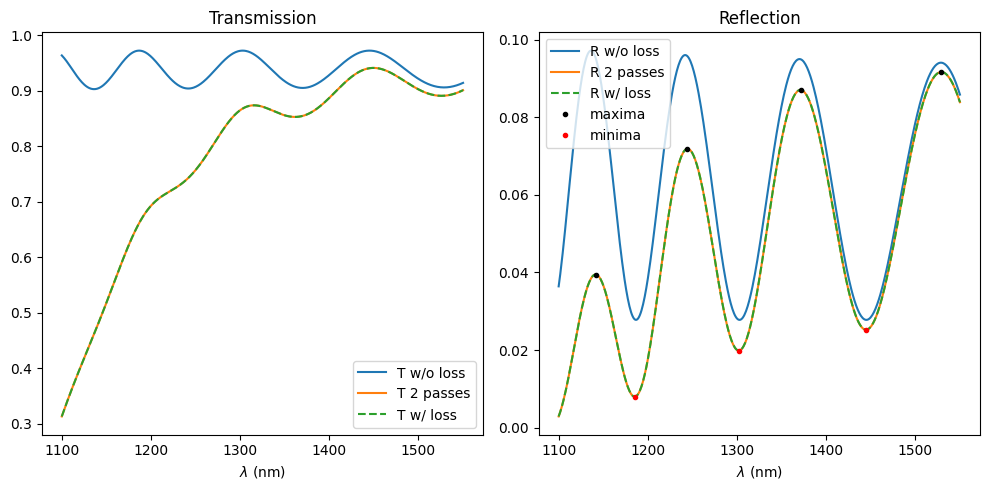

Reflection order numbers:
m_maximum = [11.44643489 10.48011008  9.49106274  8.49754323]
m_minimum = [11.00983219 10.00655059  9.00359481]


In [5]:
r1_val = r_s(0, n_s_val/n_f_val)
r2_val = r_s(0, n_o_val/n_f_val)

#Without loss
T = np.absolute(T_FP_sem_perda(r1_val, r2_val, lamb_list, n_f_val, d_f))
R = 1-T

#With loss
T_perda = np.absolute(T_FP_com_perda(r1_val, r2_val, lamb_list, n_f_val, d_f, kappa_f))
R_perda = np.absolute(R_FP_com_perda(r1_val, r2_val, lamb_list, n_f_val, d_f, kappa_f))

#Simulation of FP cavity after n passes
n_pass = 2
R_n, T_n = FP_n_passes(n_pass, n_s_val, n_f_val, n_o_val, lamb_list, d_f, kappa_f=kappa_f)


#Find maxima and minima
picos_R,_ = find_peaks(R_perda, prominence=0.001)
vales_R,_ = find_peaks(-R_perda, prominence=0.001)

#Graph
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.title('Transmission')
plt.plot (lamb_list, T, label = 'T w/o loss')
plt.plot(lamb_list, T_n, label = f'T {n_pass} passes')
plt.plot(lamb_list, T_perda, '--', label = 'T w/ loss')
plt.xlabel(r'$\lambda$ (nm)')
plt.legend()
plt.subplot(1,2,2)
plt.title('Reflection')
plt.plot(lamb_list, R, label = 'R w/o loss')
plt.plot(lamb_list, R_n, label = f'R {n_pass} passes')
plt.plot(lamb_list, R_perda, '--', label = 'R w/ loss')
plt.plot(lamb_list[picos_R], R_perda[picos_R], '.k', label="maxima")
plt.plot(lamb_list[vales_R], R_perda[vales_R], '.r', label="minima")
plt.xlabel(r'$\lambda$ (nm)')
plt.legend()
plt.tight_layout()
plt.show()

#Calculate order numbers m for reflection
try:
    n_f_max, n_f_min = n_f_val[picos_R], n_f_val[vales_R]
except TypeError:
    n_f_max, n_f_min = n_f_val, n_f_val

try:
    d_f_max, d_f_min = d_f[picos_R], d_f[vales_R]
except TypeError:
    d_f_max, d_f_min = d_f, d_f

print('Reflection order numbers:')
print(f'm_maximum = {2*n_f_max*d_f_max/lamb_list[picos_R]}')
print(f'm_minimum = {2*n_f_min*d_f_min/lamb_list[vales_R]}')

## Transmission

T_FP = 


16*n_f**2*n_s*x/(x**2*(n_f - 1)**2*(n_f - n_s)**2 - 2*x*(n_f - 1)*(n_f + 1)*(n_f - n_s)*(n_f + n_s)*cos(2*phi) + (n_f + 1)**2*(n_f + n_s)**2)

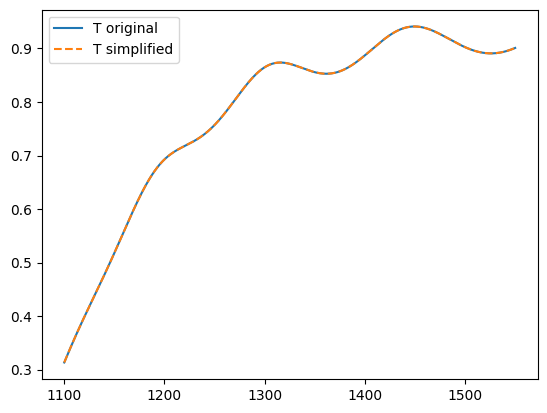

In [6]:
r1 = (n_f-n_s)/(n_s+n_f)
r2 = (n_f-n_o)/(n_f+n_o)
# r1 = (n_f-n_o)/(n_f+n_o)
# r2 = (n_f-n_s)/(n_s+n_f)
expr = (1-r1**2)*(1-r2**2)*x / (1+r1**2*r2**2*x**2-2*r1*r2*x*sp.cos(2*phi))

res_expr = expr.subs(n_o, 1)

#Solve T in terms of n_s, n_f, phi, x
T_sim = sp.expand(sp.simplify(res_expr), numer=True)
lam_T_sim = sp.lambdify([n_s, n_f, n_o, phi, x], T_sim)

T_perda = np.absolute(T_FP_com_perda(r_s(0, n_s_val/n_f_val), r_s(0, n_o_val/n_f_val), lamb_list, n_f_val, d_f, kappa_f))

plt.plot(lamb_list, T_perda, label = 'T original')
plt.plot(lamb_list, lam_T_sim(n_s_val, n_f_val, n_o_val, 2*np.pi*n_f_val/lamb_list * d_f, x_val), '--', label = 'T simplified')
plt.legend()

print('T_FP = ')
display(T_sim)

plt.show()

## Reflection

R_FP =


(x**2*(n_f - 1)**2*(n_f + n_s)**2 - 2*x*(n_f - 1)*(n_f + 1)*(n_f - n_s)*(n_f + n_s)*cos(2*phi) + (n_f + 1)**2*(n_f - n_s)**2)/(x**2*(n_f - 1)**2*(n_f - n_s)**2 - 2*x*(n_f - 1)*(n_f + 1)*(n_f - n_s)*(n_f + n_s)*cos(2*phi) + (n_f + 1)**2*(n_f + n_s)**2)

R_FP_M =


(n_f**2*x + n_f**2 + n_f*n_s*x - n_f*n_s - n_f*x + n_f - n_s*x - n_s)**2/(n_f**2*x + n_f**2 - n_f*n_s*x + n_f*n_s - n_f*x + n_f + n_s*x + n_s)**2

R_FP_m =


(n_f**2*x - n_f**2 + n_f*n_s*x + n_f*n_s - n_f*x - n_f - n_s*x + n_s)**2/(n_f**2*x - n_f**2 - n_f*n_s*x - n_f*n_s - n_f*x - n_f + n_s*x - n_s)**2

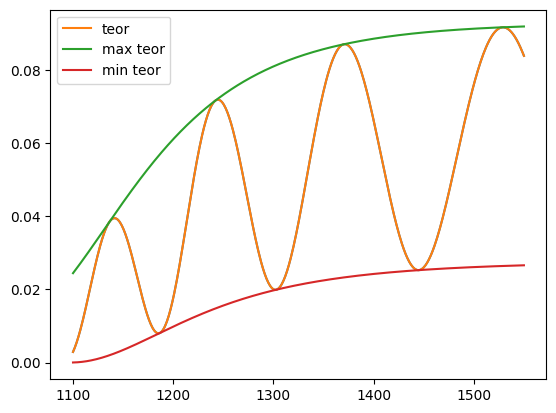

In [7]:
r1 = (n_f-n_s)/(n_s+n_f)
r2 = (n_f-n_o)/(n_f+n_o)

exprR = (r1**2+r2**2*x**2-2*r1*r2*x*sp.cos(2*phi)) / (1+r1**2*r2**2*x**2-2*r1*r2*x*sp.cos(2*phi))

res_exprR = exprR.subs(n_o, 1)
# res_exprR = res_exprR.subs(x, 1)
if np.mean(n_f_val) > np.mean(n_s_val):
    exprR_max = res_exprR.subs(sp.cos(2*phi), -1)
    exprR_min = res_exprR.subs(sp.cos(2*phi), 1)
else:
    exprR_max = res_exprR.subs(sp.cos(2*phi), 1)
    exprR_min = res_exprR.subs(sp.cos(2*phi), -1)

#Solve R_FP in terms of n_s, n_f, phi, x
R_sim = sp.simplify(res_exprR)
# R_sim = sp.factor(res_exprR)
lam_R_sim = sp.lambdify([n_s, n_f, n_o, phi, x], R_sim)

#Find expression for upper envelope R_FP_M
R_max = sp.factor(exprR_max)
lam_R_max = sp.lambdify([n_s, n_f, n_o, phi, x], R_max)

#Find expression for lower envelope R_FP_M
R_min = sp.factor(exprR_min)
lam_R_min = sp.lambdify([n_s, n_f, n_o, phi, x], R_min)

# phi_val = 2*np.pi*n_f_val/lamb_list * d_f
# r1_val = r_s(0, n_s_val/n_f_val)
# r2_val = r_s(0, n_o_val/n_f_val)

R_perda = np.absolute(R_FP_com_perda(r1_val, r2_val, lamb_list, n_f_val, d_f, kappa_f))

plt.plot(lamb_list, R_perda)

R_teor = lam_R_sim(n_s_val, n_f_val, n_o_val, 2*np.pi*n_f_val/lamb_list * d_f, x_val)
R_max_teor = lam_R_max(n_s_val, n_f_val, n_o_val, 2*np.pi*n_f_val/lamb_list * d_f, x_val)
R_min_teor = lam_R_min(n_s_val, n_f_val, n_o_val, 2*np.pi*n_f_val/lamb_list * d_f, x_val)

if type(R_teor) == float:
    plt.axhline(R_teor, label = 'teor')
else: 
    plt.plot(lamb_list, R_teor, label = 'teor')
    plt.plot(lamb_list, R_max_teor, label = 'max teor')
    plt.plot(lamb_list, R_min_teor, label = 'min teor')
plt.legend()

print('R_FP =')
display(R_sim)
print('R_FP_M =')
display(R_max)
print('R_FP_m =')
display(R_min)

plt.show()

### In the OSA

R =


(n_s + 1)**2*(x**2*(n_f - 1)**2*(n_f + n_s)**2 - 2*x*(n_f - 1)*(n_f + 1)*(n_f - n_s)*(n_f + n_s)*cos(2*phi) + (n_f + 1)**2*(n_f - n_s)**2)/((n_s - 1)**2*(x**2*(n_f - 1)**2*(n_f - n_s)**2 - 2*x*(n_f - 1)*(n_f + 1)*(n_f - n_s)*(n_f + n_s)*cos(2*phi) + (n_f + 1)**2*(n_f + n_s)**2))

R_M =


(n_s + 1)**2*(x**2*(n_f - 1)**2*(n_f + n_s)**2 + 2*x*(n_f - 1)*(n_f + 1)*(n_f - n_s)*(n_f + n_s) + (n_f + 1)**2*(n_f - n_s)**2)/((n_s - 1)**2*(x**2*(n_f - 1)**2*(n_f - n_s)**2 + 2*x*(n_f - 1)*(n_f + 1)*(n_f - n_s)*(n_f + n_s) + (n_f + 1)**2*(n_f + n_s)**2))

(n_s + 1)**2*(x*(n_f - 1)*(n_f + n_s) - (-n_f + n_s)*(n_f + 1))**2/((n_s - 1)**2*(x*(n_f - 1)*(n_f - n_s) - (-n_f - n_s)*(n_f + 1))**2)

R_m =


(n_s + 1)**2*(x**2*(n_f - 1)**2*(n_f + n_s)**2 - 2*x*(n_f - 1)*(n_f + 1)*(n_f - n_s)*(n_f + n_s) + (n_f + 1)**2*(n_f - n_s)**2)/((n_s - 1)**2*(x**2*(n_f - 1)**2*(n_f - n_s)**2 - 2*x*(n_f - 1)*(n_f + 1)*(n_f - n_s)*(n_f + n_s) + (n_f + 1)**2*(n_f + n_s)**2))

(n_s + 1)**2*(x*(n_f - 1)*(n_f + n_s) + (-n_f + n_s)*(n_f + 1))**2/((n_s - 1)**2*(x*(n_f - 1)*(n_f - n_s) + (-n_f - n_s)*(n_f + 1))**2)

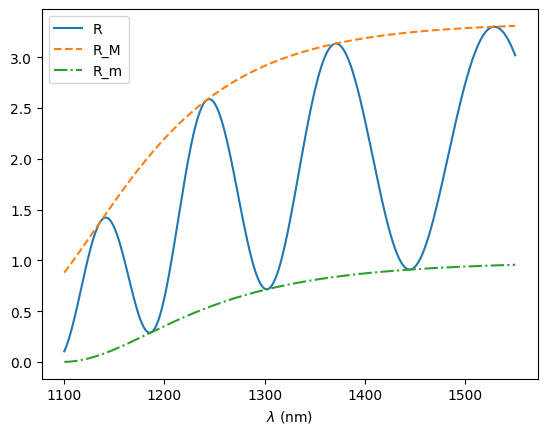

In [8]:
R_s = (n_s-1)**2/(n_s+1)**2

r1 = (n_f-n_s)/(n_s+n_f)
r2 = (n_f-n_o)/(n_f+n_o)

R_FP = (r1**2+r2**2*x**2-2*r1*r2*x*sp.cos(2*phi)) / (1+r1**2*r2**2*x**2-2*r1*r2*x*sp.cos(2*phi))

res_R_OSA = R_FP.subs(n_o, 1) / R_s

# res_R_aprox = res_R_OSA.subs(x, 1)
res_R_aprox = res_R_OSA
if np.mean(n_f_val) > np.mean(n_s_val):
    M_sign = -1
else:
    M_sign = 1

res_R_picos = res_R_aprox.subs(sp.cos(2*phi), M_sign)
res_R_vales = res_R_aprox.subs(sp.cos(2*phi), -M_sign)

R_OSA_expr = sp.simplify(res_R_OSA)
# R_OSA = simplify(expand(R_OSA))
R_M_expr = sp.simplify(res_R_picos)
R_m_expr = sp.simplify(res_R_vales)


R_M_simp = ((n_s+1) * (x*(n_s+n_f)*(n_f-1)-M_sign*(n_f-n_s)*(n_f+1)))**2 / ((n_s-1)*(x*(n_f-n_s)*(n_f-1)-M_sign*(n_s+n_f)*(n_f+1)))**2
R_m_simp = ((n_s+1) * (x*(n_s+n_f)*(n_f-1)+M_sign*(n_f-n_s)*(n_f+1)))**2 / ((n_s-1)*(x*(n_f-n_s)*(n_f-1)+M_sign*(n_s+n_f)*(n_f+1)))**2

lam_R_OSA = sp.lambdify([n_s, n_f, n_o, phi, x], R_OSA_expr)
lam_R_M_simp = sp.lambdify([n_s, n_f, x], R_M_simp)
lam_R_m_simp = sp.lambdify([n_s, n_f, x], R_m_simp)

R_OSA_val = lam_R_OSA(n_s_val, n_f_val, n_o_val, 2*np.pi*n_f_val/lamb_list * d_f, x_val)
R_M_val = lam_R_M_simp(n_s_val, n_f_val, x_val)
R_m_val = lam_R_m_simp(n_s_val, n_f_val, x_val)

print('R =')
display(R_OSA_expr)
print('R_M =')
display(R_M_expr)
display(R_M_simp)
print('R_m =')
display(R_m_expr)
display(R_m_simp)

#Graph
fig = plt.figure()
plt.plot(lamb_list, R_OSA_val, label = 'R')
plt.plot(lamb_list, R_M_val, '--', label = 'R_M') #picos
plt.plot(lamb_list, R_m_val, '-.', label = 'R_m') #vales
# plt.plot(lamb_list[picos_R], lam_R_M_simp(n_s_val, n_f_val[picos_R], x_val[picos_R]), '.')
# plt.plot(lamb_list, lam_R_OSA(n_s_val, n_f_val, n_o_val, np.pi/2, x_val), color = 'C3') #picos
# plt.plot(lamb_list, lam_R_OSA(n_s_val, n_f_val, n_o_val, 0, x_val), color = 'C4') #vales
plt.xlabel(r'$\lambda$ (nm)')
# plt.xlim(1100, 1200)
plt.legend()

#Inset graph
# max_R,_ = find_peaks(R_OSA_val)
# tan_R,_ = find_peaks(-np.abs(R_OSA_val - R_M_val))
# i_stop = max_R[0]+10
# msize = 4
# tsize = 8
# ax2 = fig.add_axes([0.6,0.17,0.28,0.28])
# plt.plot(lamb_list[:i_stop], R_OSA_val[:i_stop])
# plt.plot(lamb_list[:i_stop], R_M_val[:i_stop], '--') #picos
# plt.plot(lamb_list[:i_stop], R_m_val[:i_stop], '-.') #vales
# plt.plot(lamb_list[:i_stop][max_R[0]], R_OSA_val[:i_stop][max_R[0]], 'o', markersize = msize, color = 'C3', label = 'maximum')
# plt.plot(lamb_list[:i_stop][tan_R[0]], R_OSA_val[:i_stop][tan_R[0]], 'D', markersize = msize, color = 'C1', label = 'tangent')
# plt.legend(bbox_to_anchor=(-0.2, -0.1), loc='lower right', fontsize = 9)
# plt.xticks(fontsize = tsize)
# plt.yticks(fontsize = tsize)

plt.show()

#--Save figure--
# dir = "Figuras/"
# fmt = 'pdf'
# fig.savefig(f'{dir}R_R_m_R_M.{fmt}', format=fmt, bbox_inches='tight')

#### Solving for n_f in function of R_M and R_m

In [9]:
solution = sp.solve([(A*x+B)/(C*x+D)-R_Msqrt, (A*x-B)/(-C*x+D)-R_msqrt], x, R_msqrt, dict=True)
display(solution)

[{R_msqrt: (-2*A*B + A*D*R_Msqrt + B*C*R_Msqrt)/(A*D + B*C - 2*C*D*R_Msqrt),
  x: (-B + D*R_Msqrt)/(A - C*R_Msqrt)}]

In [10]:
expr = solution[0][R_msqrt]

expr = expr.subs(A, (n_s+1)*(n_f+n_s)*(n_f-1))
expr = expr.subs(B, -M_sign*(n_s+1)*(n_f-n_s)*(n_f+1))
expr = expr.subs(C, -M_sign*(n_s-1)*(n_f-n_s)*(n_f-1))
expr = expr.subs(D, (n_s-1)*(n_f+n_s)*(n_f+1))

solution_nf = sp.solve([expr-R_msqrt], n_f, dict = True)
display(solution_nf)

[{n_f: -sqrt((-R_Msqrt*R_msqrt*n_s**2 + 2*R_Msqrt*R_msqrt*n_s - R_Msqrt*R_msqrt + R_Msqrt*n_s**2 - R_Msqrt - R_msqrt*n_s**2 + R_msqrt + n_s**2 + 2*n_s + 1)/(-R_Msqrt*R_msqrt*n_s**2 + 2*R_Msqrt*R_msqrt*n_s - R_Msqrt*R_msqrt - R_Msqrt*n_s**2 + R_Msqrt + R_msqrt*n_s**2 - R_msqrt + n_s**2 + 2*n_s + 1))*Abs(n_s)},
 {n_f: sqrt((-R_Msqrt*R_msqrt*n_s**2 + 2*R_Msqrt*R_msqrt*n_s - R_Msqrt*R_msqrt + R_Msqrt*n_s**2 - R_Msqrt - R_msqrt*n_s**2 + R_msqrt + n_s**2 + 2*n_s + 1)/(-R_Msqrt*R_msqrt*n_s**2 + 2*R_Msqrt*R_msqrt*n_s - R_Msqrt*R_msqrt - R_Msqrt*n_s**2 + R_Msqrt + R_msqrt*n_s**2 - R_msqrt + n_s**2 + 2*n_s + 1))*Abs(n_s)}]

In [12]:
print('n_f =')
display(solution_nf[1][n_f])

expr_n_f = n_s*sp.sqrt( ((n_s+1)+M_sign*(n_s-1)*R_msqrt) * ((n_s+1)-M_sign*(n_s-1)*R_Msqrt) / ((n_s+1)-M_sign*(n_s-1)*R_msqrt) / ((n_s+1)+M_sign*(n_s-1)*R_Msqrt) )

display(sp.simplify(sp.expand(expr_n_f)))

display(expr_n_f)

n_f =


sqrt((-R_Msqrt*R_msqrt*n_s**2 + 2*R_Msqrt*R_msqrt*n_s - R_Msqrt*R_msqrt + R_Msqrt*n_s**2 - R_Msqrt - R_msqrt*n_s**2 + R_msqrt + n_s**2 + 2*n_s + 1)/(-R_Msqrt*R_msqrt*n_s**2 + 2*R_Msqrt*R_msqrt*n_s - R_Msqrt*R_msqrt - R_Msqrt*n_s**2 + R_Msqrt + R_msqrt*n_s**2 - R_msqrt + n_s**2 + 2*n_s + 1))*Abs(n_s)

n_s*sqrt((-R_Msqrt*R_msqrt*n_s**2 + 2*R_Msqrt*R_msqrt*n_s - R_Msqrt*R_msqrt + R_Msqrt*n_s**2 - R_Msqrt - R_msqrt*n_s**2 + R_msqrt + n_s**2 + 2*n_s + 1)/(-R_Msqrt*R_msqrt*n_s**2 + 2*R_Msqrt*R_msqrt*n_s - R_Msqrt*R_msqrt - R_Msqrt*n_s**2 + R_Msqrt + R_msqrt*n_s**2 - R_msqrt + n_s**2 + 2*n_s + 1))

n_s*sqrt((-R_Msqrt*(1 - n_s) + n_s + 1)*(R_msqrt*(1 - n_s) + n_s + 1)/((R_Msqrt*(1 - n_s) + n_s + 1)*(-R_msqrt*(1 - n_s) + n_s + 1)))

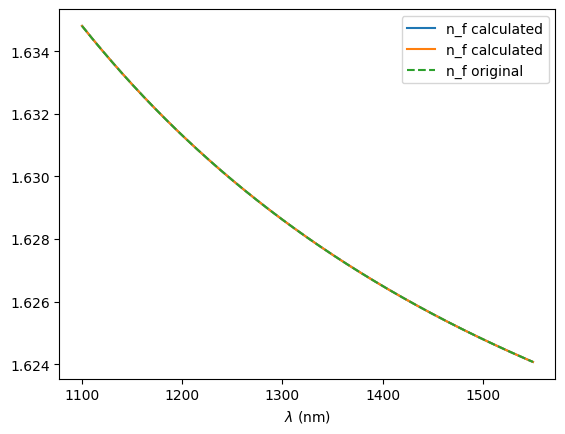

In [14]:
func_n_f = sp.lambdify([n_s, R_msqrt, R_Msqrt], expr_n_f)
n_f_calc = func_n_f(n_s_val, np.sqrt(lam_R_m_simp(n_s_val, n_f_val, x_val)), np.sqrt(lam_R_M_simp(n_s_val, n_f_val, x_val)))
n_f_calc2 = calc_n_1(n_s_val, lam_R_M_simp(n_s_val, n_f_val, x_val), lam_R_m_simp(n_s_val, n_f_val, x_val), n_f_smaller = np.mean(n_f_val)<np.mean(n_s_val))

plt.plot(lamb_list, n_f_calc, label = 'n_f calculated')
plt.plot(lamb_list, n_f_calc2, label = 'n_f calculated')
plt.plot(lamb_list, n_f_val, '--', label = 'n_f original')
plt.xlabel(r'$\lambda$ (nm)')
plt.legend()
plt.show()

#### Solving for x in function of n_f and R_M/R_m

In [11]:
solution_Mm = sp.solve([(A**2*x**2-B**2)/(D**2-C**2*x**2)-R_Msqrt*R_msqrt], x, dict=True)
solution_M = sp.solve([(A*x+B)/(C*x+D)-R_Msqrt, (A*x-B)/(-C*x+D)-R_msqrt], x, R_msqrt, dict=True)
solution_m = sp.solve([(A*x+B)/(C*x+D)-R_Msqrt, (A*x-B)/(-C*x+D)-R_msqrt], x, R_Msqrt, dict=True)

display(solution_Mm)
display(solution_M)
display(solution_m)

print('x =')
exprs = [solution_Mm[1][x], solution_M[0][x], solution_m[0][x]]

for i, expr_x in enumerate(exprs):
    expr_x = expr_x.subs(A, (n_s+1)*(n_f+n_s)*(n_f-1))
    expr_x = expr_x.subs(B, -M_sign*(n_s+1)*(n_f-n_s)*(n_f+1))
    expr_x = expr_x.subs(C, -M_sign*(n_s-1)*(n_f-n_s)*(n_f-1))
    expr_x = expr_x.subs(D, (n_s-1)*(n_f+n_s)*(n_f+1))

    display(expr_x)

[{x: -sqrt((B**2 + D**2*R_Msqrt*R_msqrt)/(A**2 + C**2*R_Msqrt*R_msqrt))},
 {x: sqrt((B**2 + D**2*R_Msqrt*R_msqrt)/(A**2 + C**2*R_Msqrt*R_msqrt))}]

[{R_msqrt: (-2*A*B + A*D*R_Msqrt + B*C*R_Msqrt)/(A*D + B*C - 2*C*D*R_Msqrt),
  x: (-B + D*R_Msqrt)/(A - C*R_Msqrt)}]

[{R_Msqrt: (2*A*B + A*D*R_msqrt + B*C*R_msqrt)/(A*D + B*C + 2*C*D*R_msqrt),
  x: (B + D*R_msqrt)/(A + C*R_msqrt)}]

x =


sqrt((R_Msqrt*R_msqrt*(n_f + 1)**2*(n_f + n_s)**2*(n_s - 1)**2 + (n_f + 1)**2*(n_f - n_s)**2*(n_s + 1)**2)/(R_Msqrt*R_msqrt*(n_f - 1)**2*(n_f - n_s)**2*(n_s - 1)**2 + (n_f - 1)**2*(n_f + n_s)**2*(n_s + 1)**2))

(R_Msqrt*(n_f + 1)*(n_f + n_s)*(n_s - 1) - (n_f + 1)*(n_f - n_s)*(n_s + 1))/(-R_Msqrt*(n_f - 1)*(n_f - n_s)*(n_s - 1) + (n_f - 1)*(n_f + n_s)*(n_s + 1))

(R_msqrt*(n_f + 1)*(n_f + n_s)*(n_s - 1) + (n_f + 1)*(n_f - n_s)*(n_s + 1))/(R_msqrt*(n_f - 1)*(n_f - n_s)*(n_s - 1) + (n_f - 1)*(n_f + n_s)*(n_s + 1))

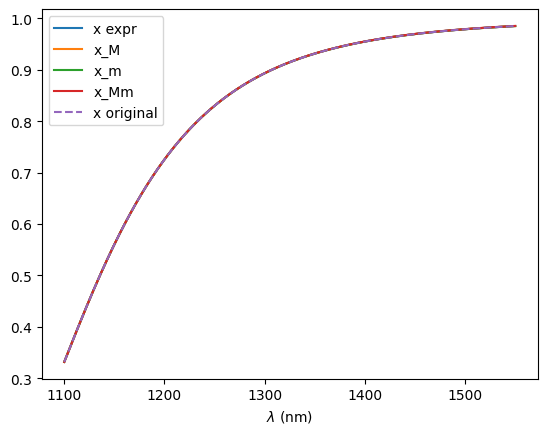

In [13]:
func_x = sp.lambdify([n_s, n_f, R_msqrt], expr_x)
x_calc_expr = func_x(n_s_val, n_f_val, np.sqrt(lam_R_m_simp(n_s_val, n_f_val, x_val)))
x_calc_M = calc_x_M(n_s_val, n_f_val, lam_R_M_simp(n_s_val, n_f_val, x_val), n_f_smaller = np.mean(n_f_val)<np.mean(n_s_val))
x_calc_m = calc_x_m(n_s_val, n_f_val, lam_R_m_simp(n_s_val, n_f_val, x_val), n_f_smaller = np.mean(n_f_val)<np.mean(n_s_val))
x_calc_Mm = calc_x_Mm(n_s_val, n_f_val, lam_R_M_simp(n_s_val, n_f_val, x_val), lam_R_m_simp(n_s_val, n_f_val, x_val))

plt.plot()
plt.plot(lamb_list, x_calc_expr, label = 'x expr')
plt.plot(lamb_list, x_calc_M, label = 'x_M')
plt.plot(lamb_list, x_calc_m, label = 'x_m')
plt.plot(lamb_list, x_calc_Mm, label = 'x_Mm')
plt.plot(lamb_list, x_val, '--', label = 'x original')
plt.xlabel(r'$\lambda$ (nm)')
plt.legend()
plt.show()